In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# Import your implementations
from students import data_processing, regression, classification, evaluation



In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

In [13]:
# Step 2: Load and Preprocess Data (you already did this)
#df = data_processing.load_heart_disease_data('../data/heart_disease_uci.csv')
df = data_processing.load_heart_disease_data('../data/heart_disease_uci.csv')

df_clean = data_processing.preprocess_data(df)
print(f"Preprocessed data shape: {df_clean.shape}")

Preprocessed data shape: (920, 15)


/Users/jawahirmohamed/BNF-5507-Winter-2026-2/test_Assignments/Assignment 2/assignment-2-supervised-learning-Jawahir-Mohamed/students/data_processing.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
/Users/jawahirmohamed/BNF-5507-Winter-2026-2/test_Assignments/Assignment 2/assignment-2-supervised-learning-Jawahir-Mohamed/students/data_processing.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


In [15]:

print("LOADING AND PREPROCESSING DATA")
print("=" * 60)

# Load data
df = data_processing.load_heart_disease_data('../data/heart_disease_uci.csv')
print(f"Raw data shape: {df.shape}")

# Preprocess data
df_clean = data_processing.preprocess_data(df)
print(f"Cleaned data shape: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")

LOADING AND PREPROCESSING DATA
Raw data shape: (920, 15)
Cleaned data shape: (920, 15)
Columns: ['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


/Users/jawahirmohamed/BNF-5507-Winter-2026-2/test_Assignments/Assignment 2/assignment-2-supervised-learning-Jawahir-Mohamed/students/data_processing.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
/Users/jawahirmohamed/BNF-5507-Winter-2026-2/test_Assignments/Assignment 2/assignment-2-supervised-learning-Jawahir-Mohamed/students/data_processing.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("\n" + "="*60)
print("PREPARING REGRESSION DATA")
print("="*60)

# Target column
target_col = 'chol'

# Features: all columns except target
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print(f"Initial Features shape: {X.shape}")
print(f"Initial Target shape: {y.shape}")

# Encode categorical features (convert text to numeric)
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category').cat.codes

# Fill missing numeric features with median
for col in X.select_dtypes(include=['int64', 'float64']).columns:
    X[col].fillna(X[col].median(), inplace=True)

# Fill missing target values
y.fillna(y.median(), inplace=True)

# Check for any remaining NaN
print(f"NaN in features: {X.isna().sum().sum()}")
print(f"NaN in target: {y.isna().sum()}")

print("\n" + "="*60)
print("SPLITTING AND SCALING DATA")
print("="*60)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}, X_test shape: {X_test_scaled.shape}")

print("\n" + "="*60)
print("TRAINING LINEAR REGRESSION MODEL")
print("="*60)

# Train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = lin_reg.predict(X_test_scaled)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.3f}")
print(f"R^2 Score: {r2:.3f}")


PREPARING REGRESSION DATA
Initial Features shape: (920, 14)
Initial Target shape: (920,)
NaN in features: 1840
NaN in target: 0

SPLITTING AND SCALING DATA
X_train shape: (736, 14), X_test shape: (184, 14)

TRAINING LINEAR REGRESSION MODEL


/var/folders/73/3gm86nbd1vvgb4zm6ybrzx440000gn/T/ipykernel_4578/1379602704.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)
/var/folders/73/3gm86nbd1vvgb4zm6ybrzx440000gn/T/ipykernel_4578/1379602704.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

# ===============================
# Load / clean data
# ===============================
df_clean = df.copy()  # assuming df is your raw dataset

# Replace common missing value markers with np.nan
missing_values = ["?", "NA", "N/A", "na", "n/a", "NaN", "nan", "", "null"]
df_clean.replace(missing_values, np.nan, inplace=True)

# Fill numeric NaNs with median, categorical NaNs with mode
for col in df_clean.columns:
    if df_clean[col].dtype in ['int64', 'float64']:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
    else:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Encode categorical variables as numeric codes
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].astype('category').cat.codes

print("Data cleaned. Shape:", df_clean.shape)

# ===============================
# 2️⃣ Regression: Predict 'chol'
# ===============================
print("\n" + "="*60)
print("REGRESSION: Predicting 'chol'")
print("="*60)

target_col = 'chol'
X_reg = df_clean.drop(columns=[target_col])
y_reg = df_clean[target_col]

# Ensure no NaNs
X_reg.fillna(X_reg.median(), inplace=True)
y_reg.fillna(y_reg.median(), inplace=True)

# Split and scale
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# Train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_reg = lin_reg.predict(X_test_reg_scaled)

# Evaluate
print("Regression Results:")
print(f"Mean Squared Error: {mean_squared_error(y_test_reg, y_pred_reg):.3f}")
print(f"R^2 Score: {r2_score(y_test_reg, y_pred_reg):.3f}")

# ===============================
# 3️⃣ Classification: Predict heart disease presence
# ===============================
print("\n" + "="*60)
print("CLASSIFICATION: Predicting heart disease presence")
print("="*60)

# Binary target: 0 = no disease, 1 = disease
target_cls = 'num'  # adjust if needed
y_cls = (df_clean[target_cls] > 0).astype(int)
y_cls.name = 'target'

# Features: exclude target and 'chol' (as per assignment instructions)
X_cls = df_clean.drop(columns=[c for c in [target_cls, 'chol'] if c in df_clean.columns])

# Ensure no NaNs
X_cls.fillna(X_cls.median(), inplace=True)

# Split and scale
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

# Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_cls_scaled, y_train_cls)
y_pred_cls = log_reg.predict(X_test_cls_scaled)

# Evaluate
print("Classification Results:")
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_cls):.3f}")
print("Classification Report:")
print(classification_report(y_test_cls, y_pred_cls))

Data cleaned. Shape: (920, 15)

REGRESSION: Predicting 'chol'
Regression Results:
Mean Squared Error: 9987.234
R^2 Score: 0.155

CLASSIFICATION: Predicting heart disease presence
Classification Results:
Accuracy: 0.804
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.83      0.78        75
           1       0.87      0.79      0.83       109

    accuracy                           0.80       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.81      0.80      0.81       184



/var/folders/73/3gm86nbd1vvgb4zm6ybrzx440000gn/T/ipykernel_4578/4287164341.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
/var/folders/73/3gm86nbd1vvgb4zm6ybrzx440000gn/T/ipykernel_4578/4287164341.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting v


Training ElasticNet grid search...
l1_ratio=0.3, alpha=0.01 -> R²=0.157
l1_ratio=0.3, alpha=0.1 -> R²=0.168
l1_ratio=0.3, alpha=1.0 -> R²=0.175
l1_ratio=0.5, alpha=0.01 -> R²=0.157
l1_ratio=0.5, alpha=0.1 -> R²=0.166
l1_ratio=0.5, alpha=1.0 -> R²=0.180
l1_ratio=0.7, alpha=0.01 -> R²=0.156
l1_ratio=0.7, alpha=0.1 -> R²=0.162
l1_ratio=0.7, alpha=1.0 -> R²=0.181

Grid search results shape: (9, 3)
R² range: 0.156 to 0.181


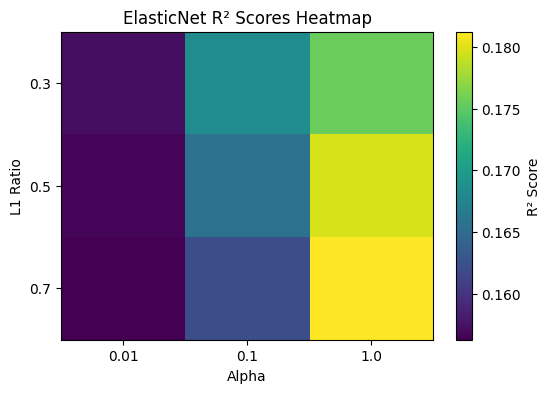


Best ElasticNet model:
  l1_ratio: 0.7
  alpha: 1.0
  Test R²: 0.181


In [25]:

# Define grid
l1_ratios = [0.3, 0.5, 0.7]
alphas = [0.01, 0.1, 1.0]

# Store results
results_list = []

print("\nTraining ElasticNet grid search...")

for l1 in l1_ratios:
    for a in alphas:
        model = ElasticNet(alpha=a, l1_ratio=l1, max_iter=5000, random_state=42)
        model.fit(X_train_reg_scaled, y_train_reg)
        y_pred = model.predict(X_test_reg_scaled)
        r2 = r2_score(y_test_reg, y_pred)
        results_list.append({'l1_ratio': l1, 'alpha': a, 'r2_score': r2})
        print(f"l1_ratio={l1}, alpha={a} -> R²={r2:.3f}")

# Convert to DataFrame
results_df = pd.DataFrame(results_list)

print(f"\nGrid search results shape: {results_df.shape}")
print(f"R² range: {results_df['r2_score'].min():.3f} to {results_df['r2_score'].max():.3f}")

# ===============================
# Heatmap of R² scores
# ===============================
heatmap_data = results_df.pivot(index='l1_ratio', columns='alpha', values='r2_score')

plt.figure(figsize=(6,4))
plt.imshow(heatmap_data, cmap='viridis', aspect='auto')
plt.colorbar(label='R² Score')
plt.xticks(ticks=np.arange(len(alphas)), labels=alphas)
plt.yticks(ticks=np.arange(len(l1_ratios)), labels=l1_ratios)
plt.xlabel('Alpha')
plt.ylabel('L1 Ratio')
plt.title('ElasticNet R² Scores Heatmap')
plt.show()

# ===============================
# Get best model
# ===============================
best_row = results_df.loc[results_df['r2_score'].idxmax()]
best_l1 = best_row['l1_ratio']
best_alpha = best_row['alpha']
best_r2 = best_row['r2_score']

print("\nBest ElasticNet model:")
print(f"  l1_ratio: {best_l1}")
print(f"  alpha: {best_alpha}")
print(f"  Test R²: {best_r2:.3f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
ElasticNet grid search results:
   l1_ratio  alpha  r2_score
0       0.3   0.01  0.217601
1       0.5   0.01  0.217503
2       0.7   0.01  0.217400
3       0.3   0.10  0.218965
4       0.5   0.10  0.218904
5       0.7   0.10  0.218555
6       0.3   1.00  0.185214
7       0.5   1.00  0.195853
8       0.7   1.00  0.207021


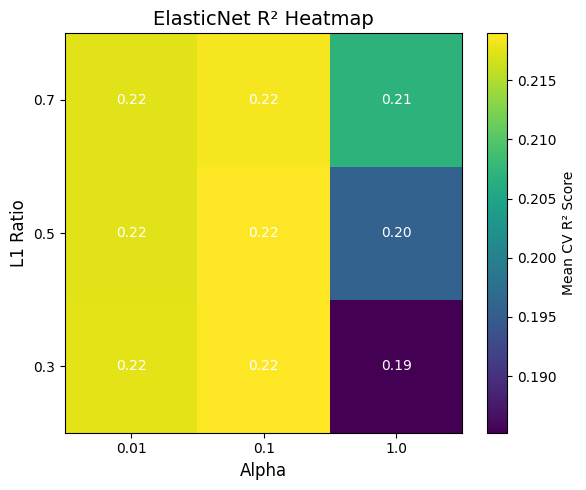


Best ElasticNet model:
  l1_ratio: 0.3
  alpha: 0.1
  CV R²: 0.219


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, make_scorer

# ------------------------------
# Define parameter grid
# ------------------------------
param_grid = {
    'alpha': [0.01, 0.1, 1.0],
    'l1_ratio': [0.3, 0.5, 0.7],
    'max_iter': [5000]
}

# ------------------------------
# ElasticNet model
# ------------------------------
elastic_net = ElasticNet()

# Use R² score as scoring metric
r2_scorer = make_scorer(r2_score)

# Grid search with 5-fold CV
grid_search = GridSearchCV(
    estimator=elastic_net,
    param_grid=param_grid,
    scoring=r2_scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search.fit(X_train_reg_scaled, y_train_reg)

# Extract results into a DataFrame
results = pd.DataFrame(grid_search.cv_results_)
results['l1_ratio'] = results['param_l1_ratio'].astype(float)
results['alpha'] = results['param_alpha'].astype(float)
results['r2_score'] = results['mean_test_score'].astype(float)

print("ElasticNet grid search results:")
print(results[['l1_ratio', 'alpha', 'r2_score']])

# ------------------------------
# Create R² heatmap
# ------------------------------
# Pivot table: rows=l1_ratio, columns=alpha
heatmap_data = results.pivot(index='l1_ratio', columns='alpha', values='r2_score')

plt.figure(figsize=(6,5))
plt.imshow(heatmap_data, cmap='viridis', origin='lower', aspect='auto')
plt.colorbar(label='Mean CV R² Score')
plt.xticks(ticks=np.arange(len(heatmap_data.columns)), labels=heatmap_data.columns)
plt.yticks(ticks=np.arange(len(heatmap_data.index)), labels=heatmap_data.index)
plt.xlabel('Alpha', fontsize=12)
plt.ylabel('L1 Ratio', fontsize=12)
plt.title('ElasticNet R² Heatmap', fontsize=14)

# Annotate heatmap with R² values
for i, l1 in enumerate(heatmap_data.index):
    for j, alpha in enumerate(heatmap_data.columns):
        plt.text(j, i, f"{heatmap_data.loc[l1, alpha]:.2f}", ha='center', va='center', color='white')

plt.tight_layout()
plt.savefig('elasticnet_r2_heatmap.png', dpi=300)
plt.show()

# ------------------------------
# Best model
# ------------------------------
best_enet = grid_search.best_estimator_
print("\nBest ElasticNet model:")
print(f"  l1_ratio: {grid_search.best_params_['l1_ratio']}")
print(f"  alpha: {grid_search.best_params_['alpha']}")
print(f"  CV R²: {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Logistic Regression model found:
  C: 0.001
  Penalty: l2
  Solver: lbfgs
  CV AUROC: nan


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Libr

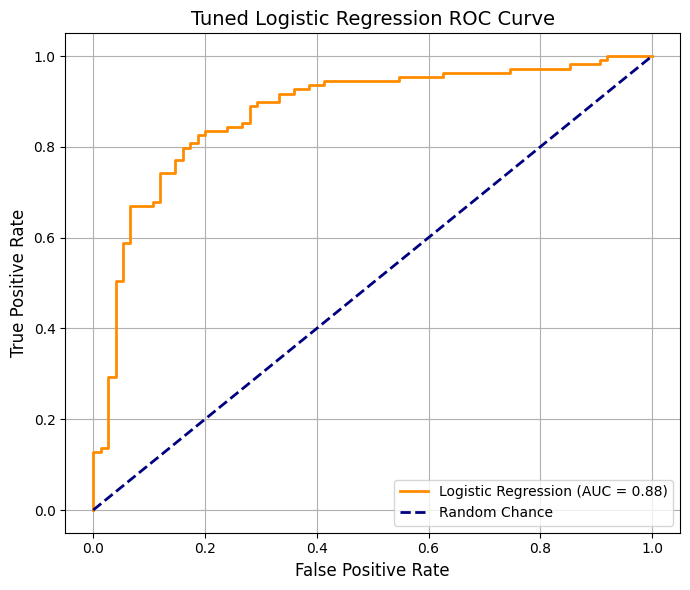

In [28]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score, make_scorer


# Logistic Regression hyperparameter grid

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [5000]  # Ensure convergence
}

log_reg = LogisticRegression()

# Use AUROC as scoring metric
roc_scorer = make_scorer(roc_auc_score, needs_proba=True)

# Grid search with 5-fold CV
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring=roc_scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search.fit(X_train_cls_scaled, y_train_cls)

# Best model
best_logreg = grid_search.best_estimator_
best_params = grid_search.best_params_
print("Best Logistic Regression model found:")
print(f"  C: {best_params['C']}")
print(f"  Penalty: {best_params['penalty']}")
print(f"  Solver: {best_params['solver']}")
print(f"  CV AUROC: {grid_search.best_score_:.3f}")

# Predict probabilities on test set
y_scores = best_logreg.predict_proba(X_test_cls_scaled)[:, 1]


# ROC Curve

fpr, tpr, _ = roc_curve(y_test_cls, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--', label='Random Chance')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Tuned Logistic Regression ROC Curve', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.savefig('tuned_logreg_ROC.png', dpi=300)
plt.show()


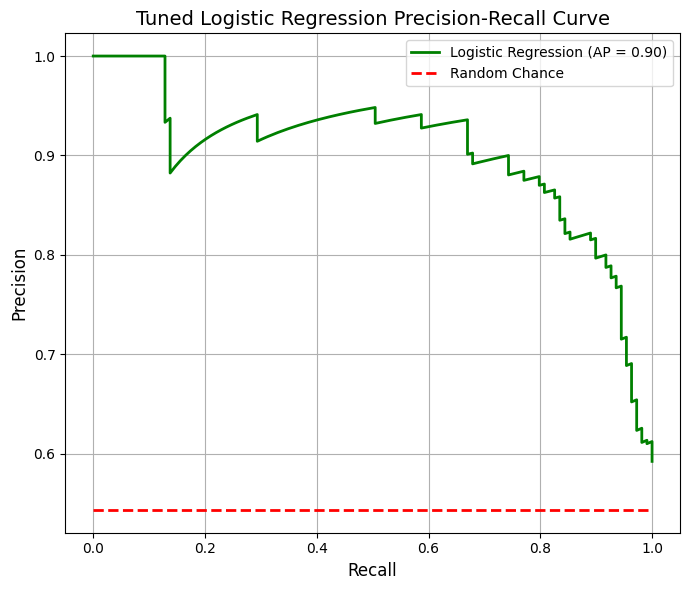

In [29]:

# Precision-Recall Curve

precision, recall, _ = precision_recall_curve(y_test_cls, y_scores)
ap_score = average_precision_score(y_test_cls, y_scores)

plt.figure(figsize=(7,6))
plt.plot(recall, precision, color='green', lw=2, label=f'Logistic Regression (AP = {ap_score:.2f})')
plt.plot([0,1], [y_train_cls.mean(), y_train_cls.mean()], color='red', lw=2, linestyle='--', label='Random Chance')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Tuned Logistic Regression Precision-Recall Curve', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.savefig('tuned_logreg_PR.png', dpi=300)
plt.show()